# Top anime data 2024
Our goal with this dataset is to predict whether the studio should spend money on production of an anime.
    to achieve this we will look into the diverse features of the Top anime data 2025 dataset
    https://www.kaggle.com/datasets/wiltheman/anime-data-set-for-ml

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('top_anime_data.csv')
df.head()

,title_english,status,episodes,rating,rank,popularity,members,favorites,score,scored_by,genres,themes,demographics
0,One Piece,Currently Airing,0.0,PG-13 - Teens 13 or older,52.0,17,2548930,239752,8.73,1449377.0,"Action, Adventure, Fantasy",NaN,Shounen
1,Fullmetal Alchemist: Brotherhood,Finished Airing,64.0,R - 17+ (violence & profanity),2.0,3,3541474,234763,9.10,2228653.0,"Action, Adventure, Drama, Fantasy",Military,Shounen
2,Hunter x Hunter,Finished Airing,148.0,PG-13 - Teens 13 or older,8.0,8,3044411,221664,9.03,1889635.0,"Action, Adventure, Fantasy",NaN,Shounen
3,Steins;Gate,Finished Airing,24.0,PG-13 - Teens 13 or older,3.0,14,2712158,196685,9.07,1470722.0,"Drama, Sci-Fi, Suspense","Psychological, Time Travel",NaN
4,Attack on Titan,Finished Airing,25.0,R - 17+ (violence & profanity),117.0,1,4188784,181378,8.56,2952092.0,"Action, Award Winning, Drama, Suspense","Gore, Military, Survival",Shounen


In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title_english  6700 non-null   object 
 1   status         10000 non-null  object 
 2   episodes       10000 non-null  float64
 3   rating         9857 non-null   object 
 4   rank           8287 non-null   float64
 5   popularity     10000 non-null  int64  
 6   members        10000 non-null  int64  
 7   favorites      10000 non-null  int64  
 8   score          9714 non-null   float64
 9   scored_by      9714 non-null   float64
 10  genres         9659 non-null   object 
 11  themes         6780 non-null   object 
 12  demographics   3122 non-null   object 
dtypes: float64(4), int64(3), object(6)
memory usage: 1015.8+ KB


# Data cleaning

### Identify Column Data Types

In [4]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print(f'Categorical columns:\n{cat_col}\n')
print(f'Numerical columns:\n{num_col}')

Categorical columns:
['title_english', 'status', 'rating', 'genres', 'themes', 'demographics']

Numerical columns:
['episodes', 'rank', 'popularity', 'members', 'favorites', 'score', 'scored_by']


## Count Unique Values in the Categorical Columns

In [5]:
df[cat_col].nunique()

title_english    6638
status              3
rating              6
genres            794
themes            848
demographics        8
dtype: int64

## Calculate Missing Values as Percentage

In [6]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

title_english    33.00
status            0.00
episodes          0.00
rating            1.43
rank             17.13
popularity        0.00
members           0.00
favorites         0.00
score             2.86
scored_by         2.86
genres            3.41
themes           32.20
demographics     68.78
dtype: float64

There's no significant gap in missing values, we should be able to replace missing values with their according mean.

### Drop null columns


In [7]:
df_clean = df

In [8]:
df_clean = df_clean.drop(columns = ['demographics'])

## Handle missing data

for text data replace missing data with "unknow"\
for other missing data:

    - rank fill with average value (mean)
    - scored_by replace with 0
    - rating fill with most frequent rating

In [9]:
df_clean['title_english'] = df_clean['title_english'].fillna('unknown ')
df_clean['themes'] = df_clean['themes'].fillna('unknown')
df_clean['genres'] = df_clean['genres'].fillna('unknown')

rank_mean = df_clean['rank'].mean()
df_clean['rank'] = df_clean['rank'].fillna(rank_mean)
df_clean['scored_by'] = df_clean['scored_by'].fillna(0)
most_freq_rating = df_clean['rating'].mode()[0]
df_clean['rating'] = df_clean['rating'].fillna(most_freq_rating)

Since 'score' is our target feature, we will drop the missing data

In [10]:
df_clean.dropna(subset=['score'], inplace=True)

In [11]:
round((df_clean.isnull().sum() / df.shape[0]) * 100, 2)

title_english    0.0
status           0.0
episodes         0.0
rating           0.0
rank             0.0
popularity       0.0
members          0.0
favorites        0.0
score            0.0
scored_by        0.0
genres           0.0
themes           0.0
dtype: float64

### Check for correlation

Our goal is to find data that is bringing out the same output, if the correlation is high we'll merge the features into one.
- rank;
- popularity;
- favorites;
- score;
- scored_by;
- members:

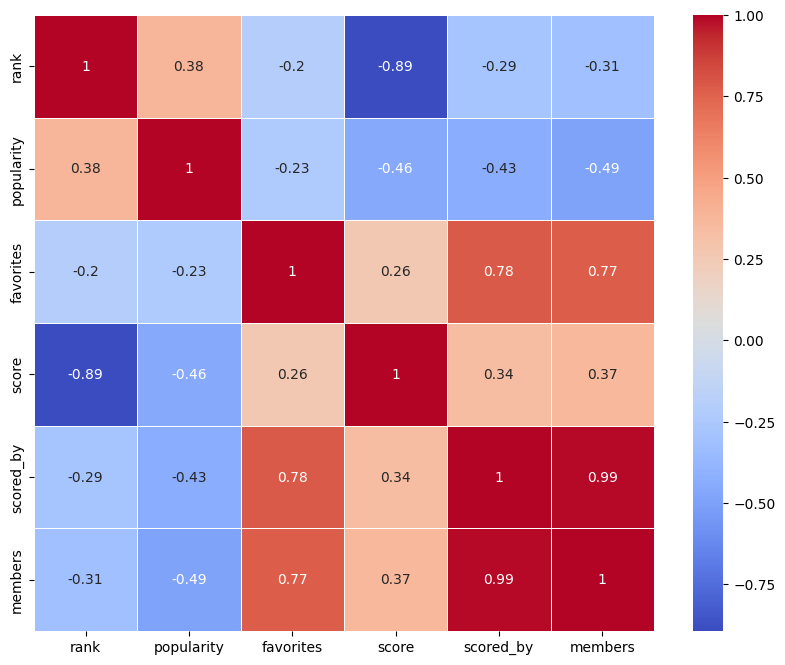

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

columns = [
    "rank",
    "popularity",
    "favorites",
    'score', 
    'scored_by',
    "members"
]

corr_matrix = df_clean[columns].corr()

plt.figure(figsize = (10, 8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', linewidths = 0.5)
plt.show()

Being that the correlation between scored_by and members is very high, we will sum them up into one, and drop the others.  More likely the members an anime has, the more members score the anime.

In [13]:
df_clean['scored_by_members'] = (df_clean['scored_by'] + df_clean['members']) / 2
df_clean = df_clean.drop(columns = ['scored_by', 'members'])

# Standardizing the data

In [14]:
df_clean.head()

,title_english,status,episodes,rating,rank,popularity,favorites,score,genres,themes,scored_by_members
0,One Piece,Currently Airing,0.0,PG-13 - Teens 13 or older,52.0,17,239752,8.73,"Action, Adventure, Fantasy",unknown,1999153.5
1,Fullmetal Alchemist: Brotherhood,Finished Airing,64.0,R - 17+ (violence & profanity),2.0,3,234763,9.10,"Action, Adventure, Drama, Fantasy",Military,2885063.5
2,Hunter x Hunter,Finished Airing,148.0,PG-13 - Teens 13 or older,8.0,8,221664,9.03,"Action, Adventure, Fantasy",unknown,2467023.0
3,Steins;Gate,Finished Airing,24.0,PG-13 - Teens 13 or older,3.0,14,196685,9.07,"Drama, Sci-Fi, Suspense","Psychological, Time Travel",2091440.0
4,Attack on Titan,Finished Airing,25.0,R - 17+ (violence & profanity),117.0,1,181378,8.56,"Action, Award Winning, Drama, Suspense","Gore, Military, Survival",3570438.0


- episodes column - it seems like currently airing animes have an episode count of 0, we will replace the 0 with the average value of episodes numbers

In [15]:
df_clean['status'] = (df_clean['status'] == 'Currently Airing').astype(int)
df_clean['episodes'] = df_clean['episodes'].replace(0, df_clean['episodes'].median())

- Genres - separate differnt genres into different features (one hot encoding)

In [16]:
df_clean_2 = df_clean.copy()

df_clean_2['genres'] = df_clean_2['genres'].str.lower().str.strip()

df_clean_2['genre_list'] = df_clean_2['genres'].str.split(',').apply(
    lambda x: [i.strip() for i in x if i.strip() != 'unknown']
)

In [17]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
encoded_genres = mlb.fit_transform(df_clean_2['genre_list'])

encoded_df = pd.DataFrame(encoded_genres, columns=mlb.classes_, index=df_clean_2.index)
df_clean = df_clean_2.join(encoded_df)
df_clean = df_clean.drop(columns = ['genres'])

In [18]:
- Themes - separate differnt themes into different features (one hot encoding)

SyntaxError: invalid syntax (489216121.py, line 1)

In [ ]:
df_clean_2 = df_clean.copy()

df_clean_2['theme_list'] = df_clean_2['themes'].str.lower().str.strip()

df_clean_2['theme_list'] = df_clean_2['theme_list'].str.split(',').apply(
    lambda x: [i.strip() for i in x if i.strip() != 'unknown']
)

encoded_themes = mlb.fit_transform(df_clean_2['theme_list'])
theme_columns = [f'theme_{cls}' for cls in mlb.classes_]
encoded_df = pd.DataFrame(encoded_themes, columns=theme_columns, index=df_clean_2.index)
df_clean = df_clean_2.join(encoded_df)
df_clean = df_clean.drop(columns = ['themes', 'theme_list'])

- rating - most of the ratings can be stripped to remove the text after ' - '   PG-13 - teens 13 or older

In [ ]:
df_clean['rating'] = df_clean['rating'].str.replace(r'\(.*\)', '', regex=True)

df_clean['rating'] = df_clean['rating'].str.split('-').str[0].str.strip()

mapping = {
    '17+': 'R',
    'All Ages': 'G',
    'Children': 'PG',
    'Teens 13 or older': 'PG-13',
    'Mild Nudity': 'R+'
}
df_clean['rating'] = df_clean['rating'].replace(mapping)

print("Cleaned Ratings:", df_clean['rating'].unique())

In [ ]:
df_clean.to_csv('anime_data_clean.csv', index=False)

print("File successfully saved as 'anime_data_clean.csv'")